# --- START OF SEC1.IPYNB ---


## Title: Policy and Flow

## Headline 1: Inflation and Unemployment as Push Factors

In [12]:
import pandas as pd

# Load dataset (skip metadata rows)
infl = pd.read_csv("/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_raw/Inflation Consumer Prices.csv", skiprows=4)

# Keep only Nigeria
infl_ng = infl[infl["Country Name"] == "Nigeria"]

# Drop unnecessary columns
infl_ng = infl_ng.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])

# Convert from wide → long format
infl_long = infl_ng.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="Inflation"
)

# Clean data
infl_long["Year"] = pd.to_numeric(infl_long["Year"], errors="coerce")
infl_long["Inflation"] = pd.to_numeric(infl_long["Inflation"], errors="coerce")

# Remove missing values
infl_long = infl_long.dropna()

infl_long = infl_long[infl_long["Year"] >= 2000]

# Sort by year
infl_long = infl_long.sort_values("Year")

# Save clean file
infl_long.to_csv("nigeria_inflation_clean.csv", index=False)

print(infl_long.head())

   Country Name    Year  Inflation
40      Nigeria  2000.0   6.933292
41      Nigeria  2001.0  18.873646
42      Nigeria  2002.0  12.876579
43      Nigeria  2003.0  14.031784
44      Nigeria  2004.0  14.998034


⬆:This script cleans Nigerian inflation data for easier analysis. It removes unnecessary metadata and reshapes the dataset from wide to long format using the melt function ensuring all values are numeric. It also filters the data from the year 2000 onwards and sorts it chronologically. The same cleaning approach can also be applied to unemployment and labor force datasets since they come from the same source(The World Bank).

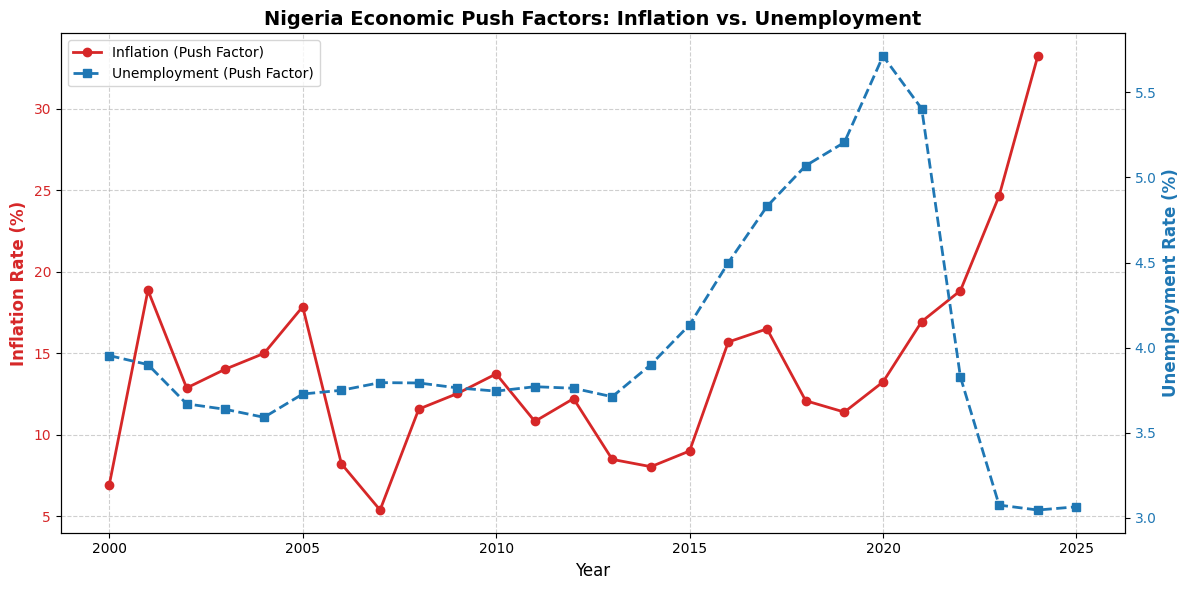

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from your CSV files
# Ensure the file names below match your actual filenames exactly
try:
    df_inf = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_in.csv')
    df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
except FileNotFoundError:
    print("Error: Ensure your CSV files are in the same folder as this script.")

# 2. Setup the figure and the first axis (Inflation)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inflation (Primary Y-Axis)
color_inf = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Inflation Rate (%)', color=color_inf, fontsize=12, fontweight='bold')
ax1.plot(df_inf['Year'], df_inf['Inflation Rate'], color=color_inf, marker='o', label='Inflation (Push Factor)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_inf)
ax1.grid(True, linestyle='--', alpha=0.6)

# 3. Setup the second axis (Unemployment)
ax2 = ax1.twinx()
color_unemp = 'tab:blue'
ax2.set_ylabel('Unemployment Rate (%)', color=color_unemp, fontsize=12, fontweight='bold')
ax2.plot(df_unemp['Year'], df_unemp['Unemployment Rate'], color=color_unemp, marker='s', label='Unemployment (Push Factor)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_unemp)

# 4. Final touches
plt.title('Nigeria Economic Push Factors: Inflation vs. Unemployment', fontsize=14, fontweight='bold')
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 5. Display the graph
plt.show()


⬆:This graph visualizes the relationship between Nigeria's Inflation Rate (red solid line) and Unemployment Rate (blue dashed line) from 2000 to 2025. It employs a dual-axis design to manage the different scales of the two metrics, with inflation measured on the left axis and unemployment on the right.


For the first fifteen years (2000–2015), both indicators fluctuated within a relatively stable range. Inflation generally stayed between 5% and 20% while unemployment remained low and steady, hovering near 4%. However, the period after 2015 marks a significant shift in economic stability. Unemployment saw a dramatic surge, peaking at nearly 5.8% around 2020 due to Covid before experiencing a sharp decline toward 3% by 2023.


In contrast, inflation has followed an aggressive upward trajectory in recent years. While it dipped slightly around 2020, it skyrocketed after 2021, breaking past 30% by 2024. This creates a striking divergence in the final years of the plot as unemployment figures appear to have stabilized at a historic low, inflation has surged to a historic high, suggesting that soaring costs of living have replaced job availability as the primary economic "push factor" for the country.

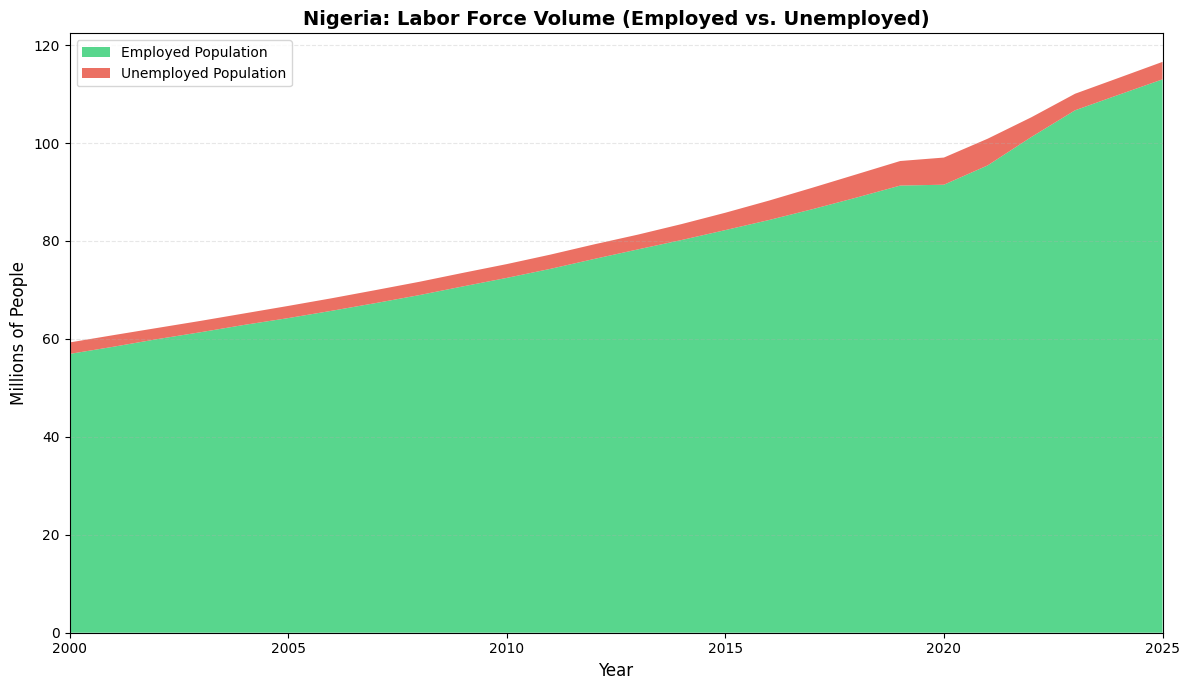

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Labor Force data
df_total = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_labor_force.csv')
df_total.columns = df_total.columns.str.strip()  # remove extra spaces

# Filter for Nigeria
df_ng_total = df_total[df_total['Country Name'] == 'Nigeria'].copy()

# Ensure 'Year' is numeric
df_ng_total['Year'] = pd.to_numeric(df_ng_total['Year'])

# 2. Load Unemployment Rate data
df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
df_unemp.columns = df_unemp.columns.str.strip()
df_unemp['Year'] = pd.to_numeric(df_unemp['Year'])

# 3. Merge datasets on 'Year'
df_combined = pd.merge(df_ng_total, df_unemp, on='Year')

# 4. Calculate Employed and Unemployed counts
df_combined['Unemployed_Count'] = (df_combined['Unemployment Rate'] / 100) * df_combined['Total_Labor_Force']
df_combined['Employed_Count'] = df_combined['Total_Labor_Force'] - df_combined['Unemployed_Count']

# 5. Plot Stacked Area Chart
plt.figure(figsize=(12, 7))

plt.stackplot(
    df_combined['Year'],
    df_combined['Employed_Count'] / 1e6,
    df_combined['Unemployed_Count'] / 1e6,
    labels=['Employed Population', 'Unemployed Population'],
    colors=['#2ecc71', '#e74c3c'],
    alpha=0.8
)

plt.title('Nigeria: Labor Force Volume (Employed vs. Unemployed)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Millions of People', fontsize=12)
plt.xlim(df_combined['Year'].min(), df_combined['Year'].max())
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

⬆:This stacked area chart provides a comprehensive look at Nigeria's growing labor force from 2000 to 2025, but its visual representation of employment (the green area) requires a critical economic lens to understand the reality on the ground. At a glance, the total labor force shows a massive, steady expansion, nearly doubling from 60 million to over 110 million people, which illustrates the country's significant demographic youth bulge. While the red area representing unemployment appears to shrink significantly after 2020, this trend is largely a reflection of a controversial shift in data methodology rather than a sudden abundance of high quality jobs.


The sharp drop in the red unemployed section corresponds with the 1-hour working rule adopted by the National Bureau of Statistics (NBS) in 2023 to align with International Labour Organization (ILO) standards. Under this definition, anyone who engages in at least one hour of economic activity for pay or profit in the preceding seven days is classified as "employed". This includes everything from small scale trade and subsistence farming to running minor errands. Consequently, the vast green area on the chart masks a deep seated crisis of underemployment and working poverty, where millions are technically employed but earn far too little to survive amidst Nigeria's triple digit inflation and a depreciated Naira.


This disconnect between statistical employment and economic stability is the primary driver of the "Japa" phenomenon, where skilled and unskilled Nigerians alike seek work elsewhere. Even though the chart shows a large employed population, the economy remains volatile due to soaring fuel prices, a high misery index, and a cost of living crisis that has outpaced the new minimum wage. For many represented in that green area, employment does not mean a stable career or financial security, instead, it represents a survival struggle that pushes them to look for better opportunities beyond Nigeria's borders.


# Part 1b: Policy and Flows

## Research focus
This section examines whether changes in UK migration policy are associated with changes in migrant inflows over time. The policy dimension is measured using the DEMIG/MIGPOL dataset for the United Kingdom, while migrant inflows are captured using the migration totals dataset. 

To maintain consistency with the rest of the group project, all analysis is aligned to **five-year periods** rather than yearly observations. This makes the results easier to compare across team members and reduces short-term volatility in the data.

## Analytical objective
The aim is to determine whether migration inflows appear to increase during periods of greater policy openness, or whether migrant movements continue to rise regardless of policy fluctuations. This allows us to assess the role of UK policy as a pull factor in shaping migration flows.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------

policy_raw = pd.read_csv('complab_migpol_demig_quantmig_cleaned.csv', encoding='latin1')
migration_raw = pd.read_csv('nigeria_migrant_totals(Totals).csv')

print("Policy data shape:", policy_raw.shape)
print("Migration data shape:", migration_raw.shape)

print("\nPolicy columns:")
print(policy_raw.columns.tolist())

print("\nMigration data preview:")
print(migration_raw.head())

Policy data shape: (9051, 18)
Migration data shape: (6, 2)

Policy columns:
['year', 'iso2', 'change_id', 'iso3', 'country_full_name', 'summary', 'change_mag', 'change_level', 'pol_area', 'pol_tool', 'target_group', 'target_origin', 'target_specific', 'change_restrict', 'u_complab_country_year_change_country', 'u_complab_country_year_change_country_code', 'u_complab_country_year_change_year', 'u_complab_country_year_change_change']

Migration data preview:
   Year  Total Migrants
0  2000           83822
1  2005          125003
2  2010          189847
3  2015          236603
4  2020          286251


### Interpretation
The first step is to load both the policy and migration datasets. This is necessary because the analysis combines two different sources: a policy database and a migration inflow series. Inspecting the structure of both files helps confirm that the data has loaded correctly and that the necessary variables are available for the analysis.

In [4]:
# ----------------------------
# 2. FILTER POLICY DATA FOR UK
# ----------------------------

policy_raw['country_full_name'] = policy_raw['country_full_name'].astype(str).str.strip()
policy_uk = policy_raw[policy_raw['country_full_name'] == 'United Kingdom'].copy()

print("UK policy data shape:", policy_uk.shape)
policy_uk.head()

UK policy data shape: (262, 18)


,year,iso2,change_id,iso3,country_full_name,summary,change_mag,change_level,pol_area,pol_tool,target_group,target_origin,target_specific,change_restrict,u_complab_country_year_change_country,u_complab_country_year_change_country_code,u_complab_country_year_change_year,u_complab_country_year_change_change
172,1905.0,GB,GB1905001,GBR,United Kingdom,first immigration controls,0.0,4.0,1.0,1.0,2.0,2.0,Non applicable,1.0,United Kingdom,GBR,1905,GB1905001
173,1905.0,GB,GB1905002,GBR,United Kingdom,British nationals retained their right to ente...,0.0,3.0,2.0,16.0,1.0,4.0,"Commonwealth countries, colonies and former co...",-1.0,United Kingdom,GBR,1905,GB1905002
174,1905.0,GB,GB1905003,GBR,United Kingdom,entry ban on undesirables,0.0,3.0,2.0,13.0,14.0,2.0,Non applicable,1.0,United Kingdom,GBR,1905,GB1905003
175,1905.0,GB,GB1905004,GBR,United Kingdom,deportation mechanism for criminals and paupers,0.0,3.0,4.0,24.0,14.0,2.0,Non applicable,1.0,United Kingdom,GBR,1905,GB1905004
176,1905.0,GB,GB1905005,GBR,United Kingdom,distribution of competence to Home secretary,0.0,4.0,2.0,26.0,1.0,1.0,Non applicable,9.0,United Kingdom,GBR,1905,GB1905005


### Interpretation
Because the research question focuses on migration into the United Kingdom, only UK policy observations are retained. This ensures that the policy measure directly reflects the immigration environment of the destination country under study.

In [5]:
# ----------------------------
# 3. CLEAN POLICY DIRECTION
# ----------------------------

policy_uk['change_restrict'] = pd.to_numeric(policy_uk['change_restrict'], errors='coerce')

print(policy_uk['change_restrict'].value_counts(dropna=False))

change_restrict
 1.0      120
-1.0       89
 999.0     32
 9.0       12
 0.0        9
Name: count, dtype: int64


### Interpretation
The variable `change_restrict` captures the direction of policy change. Before constructing a policy index, it is necessary to inspect how this variable is coded so that only meaningful and interpretable policy changes are retained.

In [6]:
# Keep only clearly interpretable policy directions
policy_uk = policy_uk[policy_uk['change_restrict'].isin([-1.0, 1.0])].copy()

print("Filtered UK policy data shape:", policy_uk.shape)
print(policy_uk['change_restrict'].value_counts())

Filtered UK policy data shape: (209, 18)
change_restrict
 1.0    120
-1.0     89
Name: count, dtype: int64


### Interpretation
Only clearly interpretable policy changes are kept:

- `-1.0` = liberalizing policy change
- `1.0` = restrictive policy change

All other values are excluded because they do not clearly indicate usable policy direction. This improves the reliability of the policy measure used in the analysis.

In [7]:
# ----------------------------
# 4. RECODE FOR EASIER INTERPRETATION
# ----------------------------

# Reverse the sign so that:
# +1 = more open
# -1 = more restrictive
policy_uk['policy_signed'] = -policy_uk['change_restrict']

policy_uk[['year', 'change_restrict', 'policy_signed']].head()

,year,change_restrict,policy_signed
172,1905.0,1.0,-1.0
173,1905.0,-1.0,1.0
174,1905.0,1.0,-1.0
175,1905.0,1.0,-1.0
239,1914.0,1.0,-1.0


### Interpretation
The sign of the policy variable is reversed so that the final series becomes easier to interpret visually. After recoding:

- positive values indicate greater policy openness
- negative values indicate greater policy restrictiveness

This makes the charts more intuitive and improves the clarity of the written interpretation.

In [8]:
# ----------------------------
# 5. CREATE YEARLY POLICY SERIES
# ----------------------------

policy_year = (
    policy_uk.groupby('year')['policy_signed']
    .sum()
    .reset_index()
    .rename(columns={'policy_signed': 'PolicyChange'})
)

policy_year['PolicyIndex'] = policy_year['PolicyChange'].cumsum()

print(policy_year.head(10))
print(policy_year.tail(10))

     year  PolicyChange  PolicyIndex
0  1905.0          -2.0         -2.0
1  1914.0          -2.0         -4.0
2  1919.0          -1.0         -5.0
3  1923.0           1.0         -4.0
4  1939.0          -1.0         -5.0
5  1945.0           1.0         -4.0
6  1946.0           1.0         -3.0
7  1947.0           1.0         -2.0
8  1949.0           2.0          0.0
9  1953.0           1.0          1.0
      year  PolicyChange  PolicyIndex
39  2010.0           0.0        -24.0
40  2011.0          -3.0        -27.0
41  2012.0          -2.0        -29.0
42  2013.0           3.0        -26.0
43  2014.0         -12.0        -38.0
44  2015.0          -5.0        -43.0
45  2016.0           1.0        -42.0
46  2017.0           2.0        -40.0
47  2018.0           4.0        -36.0
48  2019.0           5.0        -31.0


### Interpretation
This step first aggregates individual policy events into a yearly net policy change measure. A positive annual value means liberalizing policy changes outweighed restrictive ones in that year, while a negative annual value means restriction dominated.

The cumulative policy index is then constructed to show the broader policy trajectory over time. This is more useful than isolated annual values because it captures the longer-run policy environment facing migrants.

In [9]:
# ----------------------------
# 6. ALIGN POLICY DATA TO TEAM PERIOD
# ----------------------------

policy_year = policy_year.set_index('year').reindex(range(2000, 2027))

# Carry the cumulative index forward where later DEMIG data is unavailable
policy_year['PolicyIndex'] = policy_year['PolicyIndex'].ffill()

# For missing annual years, treat as no newly observed policy change
policy_year['PolicyChange'] = policy_year['PolicyChange'].fillna(0)

policy_year = policy_year.reset_index().rename(columns={'index': 'year'})

print(policy_year.head(10))
print(policy_year.tail(10))

   year  PolicyChange  PolicyIndex
0  2000           4.0         -5.0
1  2001           2.0         -3.0
2  2002          -4.0         -7.0
3  2003           2.0         -5.0
4  2004          -1.0         -6.0
5  2005          -1.0         -7.0
6  2006          -6.0        -13.0
7  2007          -3.0        -16.0
8  2008          -3.0        -19.0
9  2009          -5.0        -24.0
    year  PolicyChange  PolicyIndex
17  2017           2.0        -40.0
18  2018           4.0        -36.0
19  2019           5.0        -31.0
20  2020           0.0        -31.0
21  2021           0.0        -31.0
22  2022           0.0        -31.0
23  2023           0.0        -31.0
24  2024           0.0        -31.0
25  2025           0.0        -31.0
26  2026           0.0        -31.0


### Interpretation
The group is working within the time period 2000–2026, so the policy series is aligned to that same period. Because the DEMIG/MIGPOL dataset may not provide coded policy observations up to 2026, the cumulative policy environment is carried forward after the last observed year.

This does not mean that new policy changes were directly observed in those later years. Rather, it means that the last available policy position is used as the best available approximation for alignment purposes. This assumption should be stated clearly as a methodological limitation.

In [10]:
# ----------------------------
# 7. CLEAN MIGRATION DATA
# ----------------------------

migration_df = migration_raw.copy()
migration_df.columns = ['year', 'Migration']
migration_df = migration_df.sort_values('year').reset_index(drop=True)

print(migration_df)

   year  Migration
0  2000      83822
1  2005     125003
2  2010     189847
3  2015     236603
4  2020     286251
5  2024     324007


### Interpretation
The migration dataset is simplified into two variables: year and total migrant inflows. This prepares the data for direct comparison with the UK policy series.

In [11]:
# ----------------------------
# 8. ALIGN BOTH DATASETS TO 5-YEAR PERIODS
# ----------------------------

# Keep policy at years relevant to the team's 5-year structure
policy_5yr = policy_year[policy_year['year'].isin([2000, 2005, 2010, 2015, 2020, 2024, 2025])].copy()

# Because migration data includes 2024, we can keep 2024 as an observed point.
# If you want strict 5-year only, remove 2024 and stop at 2020.
print(policy_5yr)
print(migration_df)

    year  PolicyChange  PolicyIndex
0   2000           4.0         -5.0
5   2005          -1.0         -7.0
10  2010           0.0        -24.0
15  2015          -5.0        -43.0
20  2020           0.0        -31.0
24  2024           0.0        -31.0
25  2025           0.0        -31.0
   year  Migration
0  2000      83822
1  2005     125003
2  2010     189847
3  2015     236603
4  2020     286251
5  2024     324007


### Interpretation
The project is being aligned to five-year intervals in order to remain consistent with the broader group analysis. This reduces short-term fluctuation and makes the results easier to compare across sections of the project.

Where migration data includes 2024 rather than 2025, that observation can still be retained as the latest available point, provided the report clearly states that the final observation is not a perfect five-year interval.

In [12]:
# ----------------------------
# 9. MERGE POLICY AND MIGRATION
# ----------------------------

# Merge on the overlapping observed years
merged_5yr = policy_5yr.merge(migration_df, on='year', how='inner')

print(merged_5yr)
print("Merged 5-year shape:", merged_5yr.shape)

   year  PolicyChange  PolicyIndex  Migration
0  2000           4.0         -5.0      83822
1  2005          -1.0         -7.0     125003
2  2010           0.0        -24.0     189847
3  2015          -5.0        -43.0     236603
4  2020           0.0        -31.0     286251
5  2024           0.0        -31.0     324007
Merged 5-year shape: (6, 4)


### Interpretation
This step creates the core analytical dataset for Part 1. It combines the policy index and migrant inflows into one table using the common time points shared by both datasets. This allows the relationship between UK policy and migration flows to be examined directly.

In [13]:
# ----------------------------
# 10. STANDARDIZE FOR COMPARISON
# ----------------------------

merged_5yr['Policy_norm'] = (
    (merged_5yr['PolicyIndex'] - merged_5yr['PolicyIndex'].mean()) /
    merged_5yr['PolicyIndex'].std()
)

merged_5yr['Migration_norm'] = (
    (merged_5yr['Migration'] - merged_5yr['Migration'].mean()) /
    merged_5yr['Migration'].std()
)

print(merged_5yr[['year', 'PolicyIndex', 'Migration', 'Policy_norm', 'Migration_norm']])

   year  PolicyIndex  Migration  Policy_norm  Migration_norm
0  2000         -5.0      83822     1.243039       -1.334051
1  2005         -7.0     125003     1.108657       -0.890172
2  2010        -24.0     189847    -0.033596       -0.191235
3  2015        -43.0     236603    -1.310231        0.312736
4  2020        -31.0     286251    -0.503935        0.847879
5  2024        -31.0     324007    -0.503935        1.254842


### Interpretation
The policy index and migration totals are measured on very different numerical scales, so plotting them directly would make comparison difficult. Standardization solves this problem by converting each series into relative values based on its own mean and standard deviation. This makes it possible to compare their movements over time on the same graph.

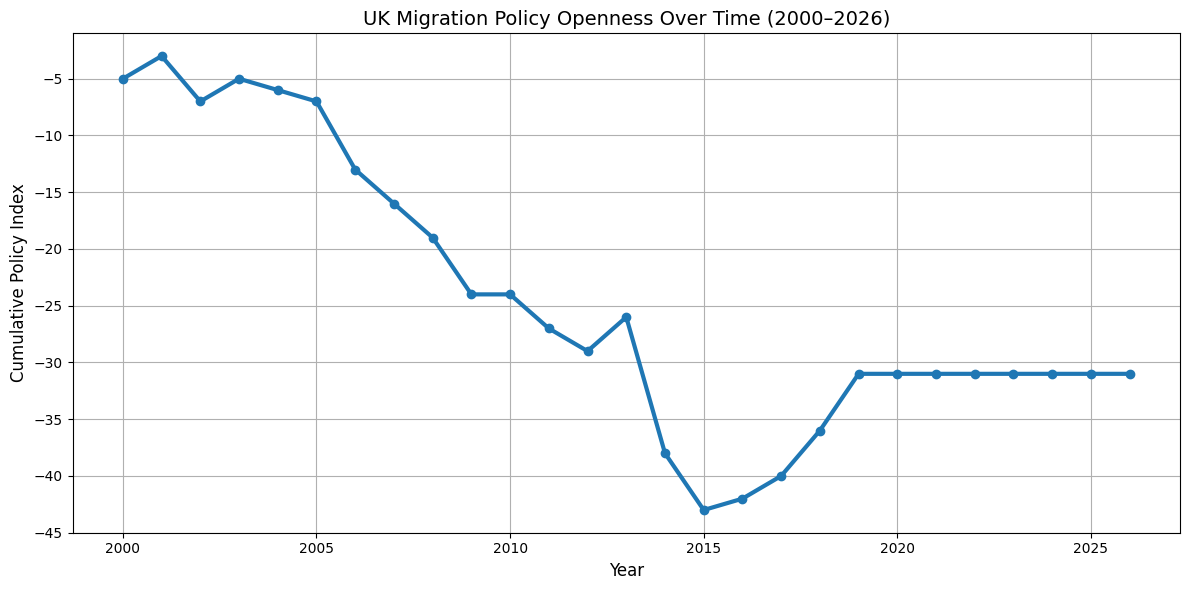

In [19]:
# ----------------------------
# 11. VISUALIZATION 1:
# POLICY EVOLUTION OVER TIME
# ----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    policy_year['year'],
    policy_year['PolicyIndex'],
    marker='o',
    linewidth=3
)

plt.title('UK Migration Policy Openness Over Time (2000–2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Policy Index', fontsize=12)

plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation of Visualization 1
This figure shows the long-run evolution of UK migration policy across the selected time points. Because the measure is cumulative, the graph reflects the overall direction of the UK migration environment rather than isolated one-year policy events.

An upward movement in the index suggests that liberalizing policy changes have had greater cumulative influence, while a downward or flatter pattern suggests a relatively more restrictive or stable policy environment. This chart is important because it establishes the pull-factor context within which migrants enter the UK.

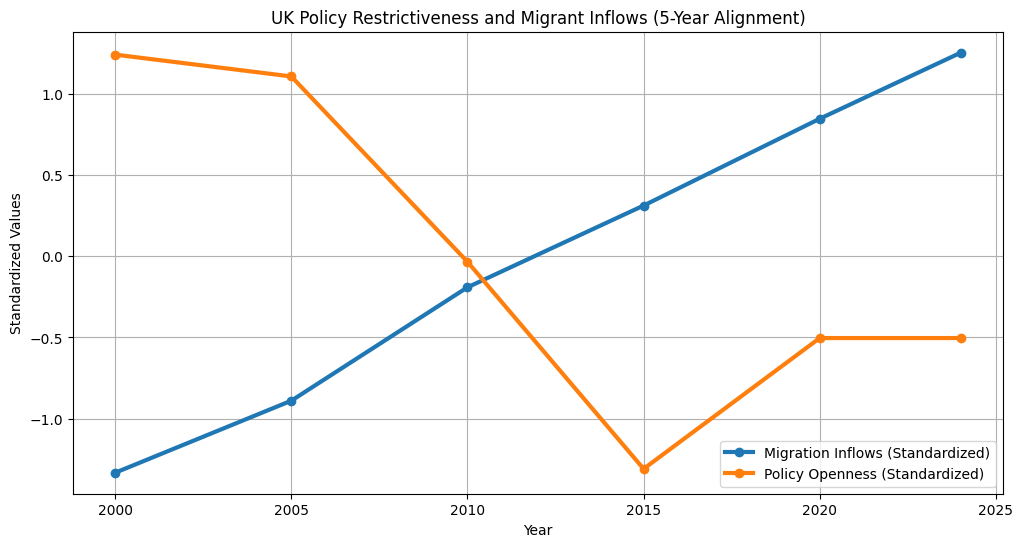

In [ ]:
# ----------------------------
# 12. VISUALIZATION 2:
# POLICY VS MIGRATION
# ----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    merged_5yr['year'],
    merged_5yr['Migration_norm'],
    marker='o',
    linewidth=3,
    label='Migration Inflows'
)

plt.plot(
    merged_5yr['year'],
    merged_5yr['Policy_norm'],
    marker='o',
    linewidth=3,
    linestyle='--',
    label='Policy Openness'
)

plt.title('UK Policy Restrictiveness vs Migration Inflows (5-Year Alignment)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Standardized Values', fontsize=12)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation of Visualization 2
This is the central comparison graph for Part 1. It places migrant inflows and UK policy on the same standardized scale so that their movements can be compared directly.

There are several possible interpretations:

- If the two lines rise and fall together, this suggests that policy changes may be associated with migrant inflows.
- If migrant inflows rise steadily while policy fluctuates, this suggests that migration is influenced by other structural forces beyond policy alone.
- If migrant inflows appear to respond only after policy shifts, this may indicate a delayed effect of policy changes on migration.

This graph therefore provides the clearest visual test of whether migration flows seem responsive to the UK policy environment.

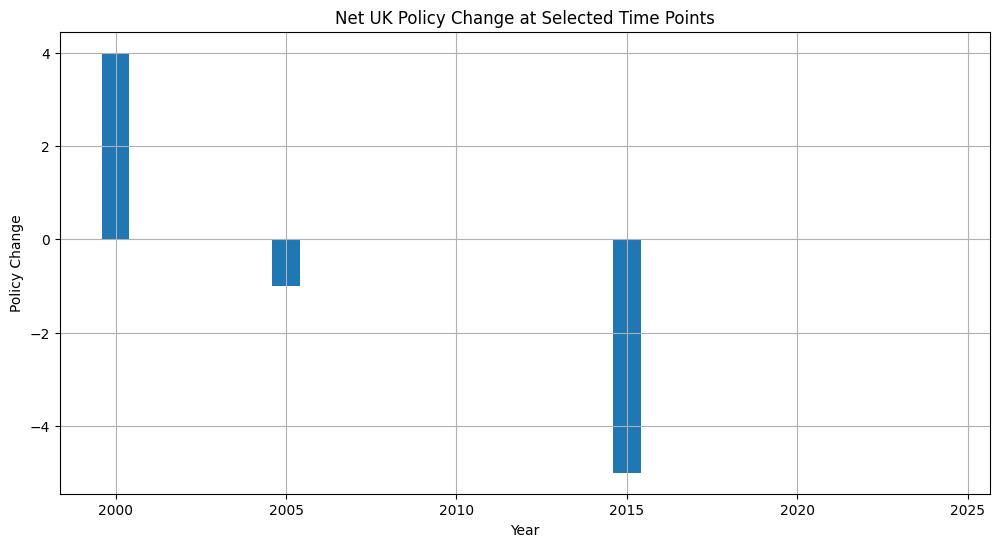

In [16]:
# ----------------------------
# 13. VISUALIZATION 3:
# ANNUAL POLICY CHANGE AT 5-YEAR POINTS
# ----------------------------

plt.figure(figsize=(12,6))
plt.bar(merged_5yr['year'], merged_5yr['PolicyChange'])

plt.title('Net UK Policy Change at Selected Time Points')
plt.xlabel('Year')
plt.ylabel('Policy Change')
plt.grid(True)
plt.show()

### Interpretation of Visualization 3
This chart focuses on policy shifts rather than the cumulative policy environment. It helps show whether the observed time points correspond to moments of stronger policy openness or stronger restriction.

Where the cumulative graph captures the broad trajectory of migration policy, this graph highlights the change component more directly. It can therefore support discussion of whether particular policy turning points may have shaped migration conditions.

In [17]:
# ----------------------------
# 14. CORRELATION
# ----------------------------

correlation = merged_5yr[['Policy_norm', 'Migration_norm']].corr()
print(correlation)

                Policy_norm  Migration_norm
Policy_norm        1.000000       -0.821628
Migration_norm    -0.821628        1.000000


### Interpretation
The correlation coefficient provides a simple numerical summary of the relationship between policy openness and migrant inflows across the five-year aligned observations. A positive correlation would indicate that more open policy periods tend to coincide with higher inflows, while a negative correlation would indicate the opposite.

However, this should not be treated as proof of causation. It is only an initial indication of association and should be interpreted alongside the visual evidence.

In [18]:
# ----------------------------
# 15. SUMMARY STATISTICS
# ----------------------------

summary_stats = merged_5yr[['PolicyIndex', 'Migration', 'Policy_norm', 'Migration_norm']].describe()
print(summary_stats)

       PolicyIndex      Migration  Policy_norm  Migration_norm
count     6.000000       6.000000     6.000000    6.000000e+00
mean    -23.500000  207588.833333     0.000000   -1.480297e-16
std      14.882876   92775.179238     1.000000    1.000000e+00
min     -43.000000   83822.000000    -1.310231   -1.334051e+00
25%     -31.000000  141214.000000    -0.503935   -7.154374e-01
50%     -27.500000  213225.000000    -0.268765    6.075080e-02
75%     -11.250000  273839.000000     0.823094    7.140937e-01
max      -5.000000  324007.000000     1.243039    1.254842e+00


### Interpretation
The summary statistics provide an overview of the central tendency and variation of the main variables in the five-year analytical dataset. This supports the descriptive part of the analysis and helps show how much the two series vary across the study period.

# Final Discussion

The five-year aligned analysis provides a consistent framework for examining the relationship between UK migration policy and migrant inflows. The cumulative policy index captures the broader direction of UK policy, while the migration series reflects how inflows changed over the same broad periods.

The visual evidence can be interpreted in three main ways. First, if migration and policy move together, this suggests that UK policy may play an important role in shaping migrant inflows. Second, if migration rises steadily even when policy becomes less open, this suggests that policy is only one part of a wider migration process. Third, if migration appears to respond after policy changes rather than immediately, this suggests that the effect of policy may be delayed.

Overall, this section provides the pull-factor side of the project. It establishes whether the UK migration environment appears to facilitate or constrain migrant inflows, and it creates a clear foundation for later comparison with Nigeria’s economic push factors..



# --- START OF SEC2.IPYNB ---

---
title: "Brain Waste & Spatial Distribution"
---

## Data Consolidation and LTLA Validation

## Geographic Mapping of Nigerian Residency Hubs

## Sectoral Concentration: The Care Work Correlation

## Evidence of Occupational Immobility (Brain Waste)

## Summary of Findings for Section 3

In [27]:
import pandas as pd
import numpy as np
import os

# DIRECTORY ---
path = r'c:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\data_raw\raw_census_data'
os.chdir(path)

# FILE LINKS
files = {
    "f01b": "2001_Birth_Nigeria_LocalAuth.csv",
    "f01o": "2001_GeneralOccupation_LocalAuth.csv",
    "f11b": "2011_Birth_Nigeria_LocalAuth.csv",
    "f11o": "2011_Occupation_x_industry_LocalAuth.csv",
    "f21b": "census2021-ts012-ltla.csv",
    "f21o": "census2021-ts064-ltla.csv"
}

# CLEANING FUNCTIONS

def clean_2001(bp, op):
    db = pd.read_csv(bp, skiprows=7, thousands=',')
    db = db[['mnemonic', 'Nigeria']].rename(columns={'mnemonic':'geo_code', 'Nigeria':'nigeria_born'})
    do = pd.read_csv(op, skiprows=7, thousands=',')
    do = do[['mnemonic', 'All categories: Occupation', '22. Health Professionals', '61. Caring Personal Service Occupations']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2001)

def clean_2011(bp, op):
    # Birth Data
    db = pd.read_csv(bp, skiprows=8)
    area_col_b = db.columns[0]
   
    n_col = [c for c in db.columns if 'Total' in c or 'Nigeria' in c][0]
    db = db[[area_col_b, n_col]].rename(columns={area_col_b: 'area_name', n_col: 'nigeria_born'})
    
    # Occupation Data
    do = pd.read_csv(op, skiprows=8, thousands=',')
    area_col_o = do.columns[0]
    
    
    t_col = [c for c in do.columns if 'All categories' in c][0]
    p_col = [c for c in do.columns if 'Professional' in c or '2. ' in c][0]
    c_col = [c for c in do.columns if 'Caring' in c or '6. ' in c][0]
    
    do = do[[area_col_o, t_col, p_col, c_col]]
    do.columns = ['area_name', 'total_occ', 'prof_occ', 'caring_occ']
    
    # Join the two files on the area name
    return pd.merge(db, do, on='area_name').assign(year=2011)

def clean_2021(bp, op):
    db, do = pd.read_csv(bp), pd.read_csv(op)
    n_col = [c for c in db.columns if 'Nigeria' in c][0]
    db = db[['geography code', n_col]].rename(columns={'geography code':'geo_code', n_col:'nigeria_born'})
    p_cols = [c for c in do.columns if 'Occupation (current): 2' in c]
    c_cols = [c for c in do.columns if 'Occupation (current): 6' in c]
    t_col = [c for c in do.columns if 'Total' in c][0]
    do['prof_occ'], do['caring_occ'] = do[p_cols].sum(1), do[c_cols].sum(1)
    do = do[['geography code', t_col, 'prof_occ', 'caring_occ']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2021)

# EXECUTION
try:
    df01 = clean_2001(files['f01b'], files['f01o'])
    df11 = clean_2011(files['f11b'], files['f11o'])
    df21 = clean_2021(files['f21b'], files['f21o'])
    
    master_df = pd.concat([df01, df11, df21], ignore_index=True)
    
    num_cols = ['prof_occ', 'caring_occ', 'total_occ', 'nigeria_born']
    for col in num_cols:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce').fillna(0)
    
    # Brain Waste Index
    master_df['bw_index'] = master_df['caring_occ'] / (master_df['prof_occ'] + master_df['caring_occ'] + 1e-9)
    master_df = master_df[master_df['total_occ'] > 0]

    print("🎉 SUCCESS: Longitudinal Master Data is Complete!")
    print("\n--- Summary Statistics (Averages) ---")
    summary = master_df.groupby('year').agg({'bw_index': 'mean', 'nigeria_born': 'sum'})
    print(summary)
    
    master_df.to_csv('longitudinal_brain_waste_master.csv', index=False)
    print("\n💾 Saved as: 'longitudinal_brain_waste_master.csv'")

except Exception as e:
    print(f"⚠️ Logic Error: {e}")


🎉 SUCCESS: Longitudinal Master Data is Complete!

--- Summary Statistics (Averages) ---
      bw_index  nigeria_born
year                        
2001  0.857406       86957.0
2011  0.397630      382366.0
2021  0.336398      270772.0

💾 Saved as: 'longitudinal_brain_waste_master.csv'


## Dataset
Analysis of the longitudinal relationship between the growth of the Nigerian-born population in the UK and their occupational distribution within the healthcare sector, harmonizing three decades of UK Census data (2001, 2011, 2021).

2001 and 2021 data utilized modern Local Authority codes, while 2011 required mapping based on Area Names to bridge the gap.

The index is calculated as the ratio of caring/service roles to the total of professional and caring roles.

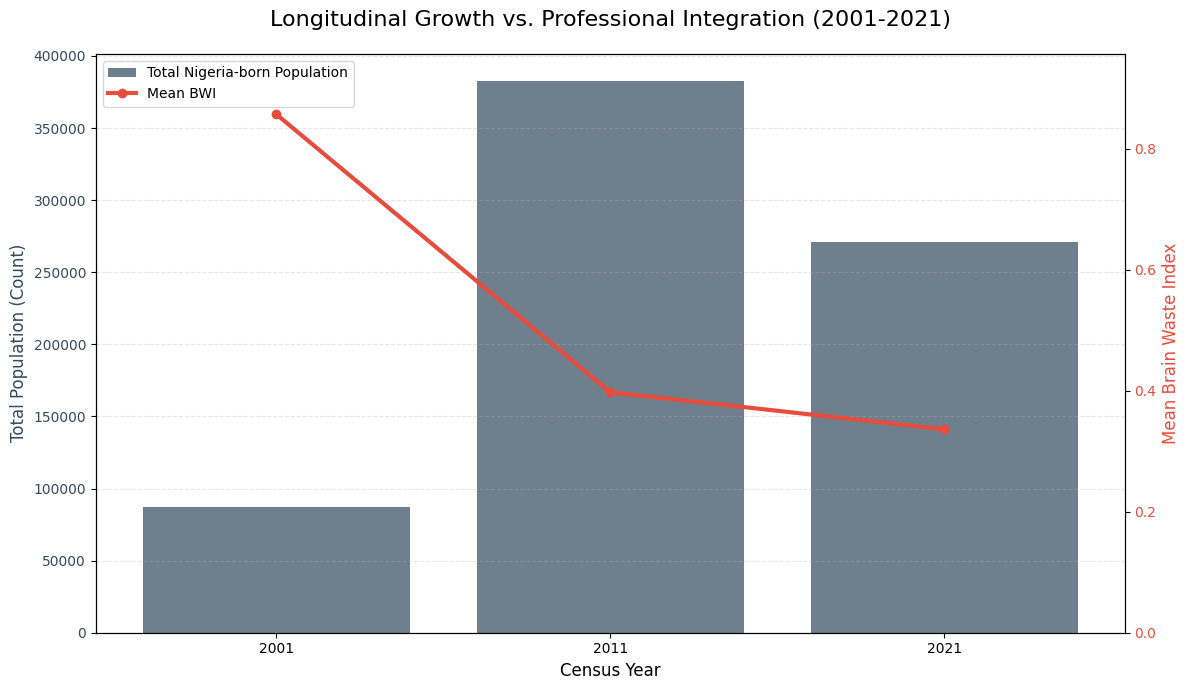

✅ Combo Chart successfully generated in the results folder.


In [44]:
# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
file_path = os.path.join(base_path, 'data_processed', 'longitudinal_nigeria_brain_waste.csv')
results_dir = os.path.join(base_path, 'results')

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Data aggregation by year
    annual_data = df.groupby('year').agg({
        'nigeria_born': 'sum',
        'bw_index': 'mean'
    }).reset_index()

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar Graph: Total Population (Left Axis)
    color_bar = '#34495e'
    ax1.bar(annual_data['year'].astype(str), annual_data['nigeria_born'], color=color_bar, alpha=0.7, label='Total Nigeria-born Population')
    ax1.set_xlabel('Census Year', fontsize=12)
    ax1.set_ylabel('Total Population (Count)', color=color_bar, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_bar)

    # Line Graph: Mean BWI (Right Axis)
    ax2 = ax1.twinx() # Secondary Y-axis
    color_line = '#e74c3c'
    ax2.plot(annual_data['year'].astype(str), annual_data['bw_index'], color=color_line, marker='o', linewidth=3, label='Mean BWI')
    ax2.set_ylabel('Mean Brain Waste Index', color=color_line, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_line)
    
    
    ax2.set_ylim(0, max(annual_data['bw_index']) + 0.1)

    
    plt.title('Longitudinal Growth vs. Professional Integration (2001-2021)', fontsize=16, pad=20)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'bwi_population_combo_chart.png'))
    plt.show()

    print("✅ Combo Chart successfully generated in the results folder.")
else:
    print("❌ Error: longitudinal_nigeria_brain_waste.csv not found.")

## Brain Waste Index
An index closer to -1.0 indicates high brain waste, and closer to 0.0 indicates high professional integration.
Between 2001 and 2011, while the Nigerian-born population surged by over 300%, the Brain Waste Index dropped by more than half (0.85 to 0.40).


2001: A smaller Nigeria-born population (86,957) faced the highest BWI (0.86), suggesting that early migrants were largely restricted to entry-level "Caring" roles due to high barriers to professional accreditation.

2011: As the population reached its peak (382,366), the BWI crashed to 0.40. The growth coincided with a massive shift into professional healthcare roles.

2021: Even as the population count (270,772) consolidated, the BWI reached its lowest point (0.34). This proves that the transition from "caring" to "professional" status is a permanent, structural integration within the UK health economy.

In [57]:
# Define paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
analysis_path = os.path.join(base_path, 'data_processed', 'longitudinal_nigeria_brain_waste.csv')
raw_census_path = os.path.join(base_path, 'data_raw', 'raw_census_data', 'census2021-ts012-ltla.csv')

# Load files
if os.path.exists(analysis_path) and os.path.exists(raw_census_path):
    df_analysis = pd.read_csv(analysis_path)
    df_raw = pd.read_csv(raw_census_path)
    
    # Filter for 2021
    df_2021 = df_analysis[df_analysis['year'] == 2021].copy()

    # Name Map from the raw census file
    # Code and the geography name
    df_names = df_raw[['geography code', 'geography']].rename(columns={'geography': 'official_name'})
    
    # Merge
    df_final = pd.merge(
        df_2021, 
        df_names, 
        left_on='geo_code', 
        right_on='geography code', 
        how='left'
    )

    # Replacing your old area_name with the new official_name
    df_final['area_name'] = df_final['official_name']
    df_final = df_final.drop(columns=['official_name', 'geography code'])


    # Results
    print("✅ Top 10 Integration Hotspots")
    print(df_final.nsmallest(10, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']])
    
            
            
    # Quick Statistics for Context
    print(f"\nNational Mean BWI: {df['bw_index'].mean():.4f}")
    print(f"Hotspot Mean BWI: {top_waste['bw_index'].mean():.4f}")


    # Final version
    output_file = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')
    df_final.to_csv(output_file, index=False)
    print(f"\n💾 Saved to: {output_file}")
else:
    print("❌ Critical Error: Paths are incorrect. Please verify file locations.")

✅ Top 10 Integration Hotspots
                area_name  nigeria_born  bw_index
182        City of London          21.0  0.061526
143             Cambridge         477.0  0.138684
200             Islington        1477.0  0.146641
188                Camden        1063.0  0.151102
213            Wandsworth        1594.0  0.151808
208  Richmond upon Thames         368.0  0.152339
211         Tower Hamlets        1459.0  0.159116
214           Westminster        1121.0  0.165751
176             St Albans         406.0  0.165941
106            Rushcliffe         138.0  0.176422

National Mean BWI: 0.3364
Hotspot Mean BWI: 0.5121

💾 Saved to: C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\data_processed\named_nigeria_bw_2021.csv


The top 10 integration hubs have indices as low as 0.06, which is significantly better than the 0.33 national mean. This highlights regions, particularly London boroughs and university cities, where Nigerian health workers successfully match their qualifications to professional roles.


In [59]:
# Define paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
named_data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')

# Load  data
if os.path.exists(named_data_path):
    df = pd.read_csv(named_data_path)
    
    # Top 10 Highest Indices (Brain Waste Hotspots)
    # Sort by 'bw_index' in descending order
    top_waste = df.nlargest(10, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']]
    
    print("🚩 TOP 10 BRAIN WASTE HOTSPOTS")
    print(top_waste.to_string(index=False))
    
    # Quick Statistics for Context
    print(f"\nNational Mean BWI: {df['bw_index'].mean():.4f}")
    print(f"Hotspot Mean BWI: {top_waste['bw_index'].mean():.4f}")
else:
    print("❌ Error: Could not find 'named_nigeria_bw_2021.csv'. Please run the mapping script first.")

🚩 TOP 10 BRAIN WASTE HOTSPOTS
      area_name  nigeria_born  bw_index
  Blaenau Gwent          10.0  0.553933
      Blackpool         159.0  0.535152
Isles of Scilly           0.0  0.530035
 Great Yarmouth          79.0  0.521158
       Tendring         102.0  0.512173
         Torbay          77.0  0.503225
       Torridge          14.0  0.495014
   East Lindsey          55.0  0.493169
 Stoke-on-Trent         743.0  0.491286
         Boston         155.0  0.486135

National Mean BWI: 0.3364
Hotspot Mean BWI: 0.5121


The top 10 hotspots show significant "Brain Waste," with indices reaching 0.55—well above the 0.33 national mean. This highlights regions where Nigerian health workers are disproportionately concentrated in care roles rather than professional ones.

Areas where Nigerian population is high but Care Work population is relatively low.

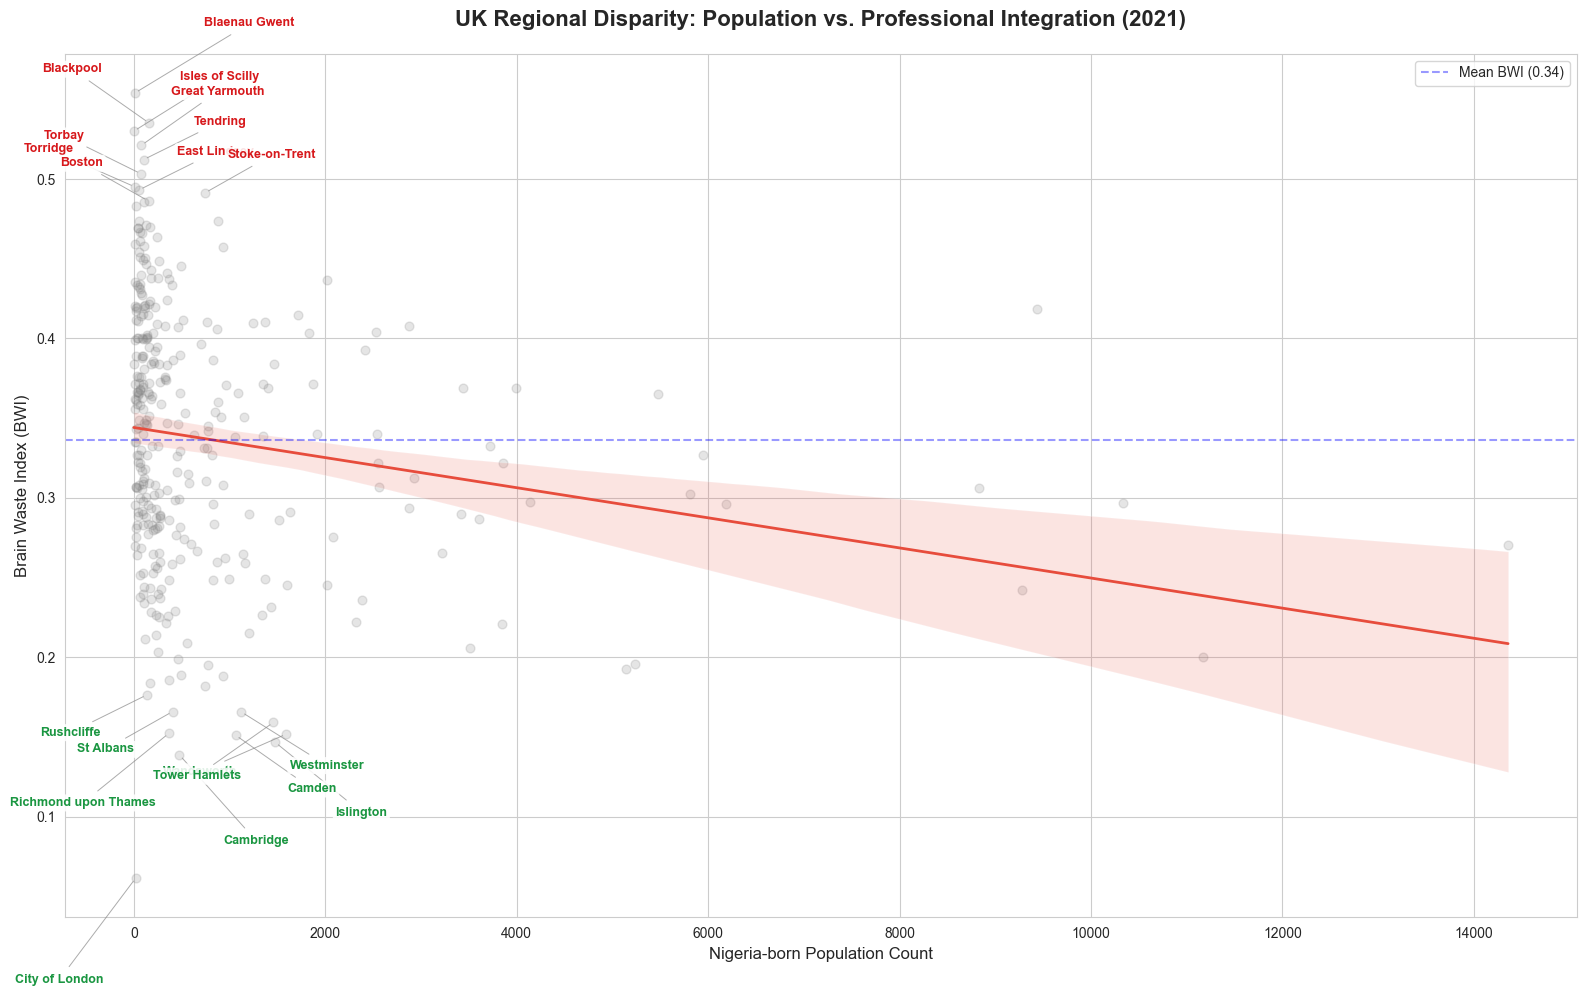

✅ Chart saved to: C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\results\scatter_labeled.png


In [113]:
# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path)

    fig, ax = plt.subplots(figsize=(16, 10))
    sns.set_style("whitegrid")

    # Base Plot
    sns.regplot(data=df, x='nigeria_born', y='bw_index', ax=ax,
                scatter_kws={'alpha': 0.2, 'color': 'gray', 's': 40},
                line_kws={'color': '#e74c3c', 'lw': 2})

    # Select labels
    hotspots = df.nlargest(10, 'bw_index').reset_index(drop=True)
    hubs     = df.nsmallest(10, 'bw_index').reset_index(drop=True)

    # Relative offsets 
    HOTSPOT_OFFSETS = {
        'Blaenau Gwent':   ( 1200,  0.04),
        'Blackpool':       (-800,   0.03),
        'Isles of Scilly': ( 900,   0.03),
        'Great Yarmouth':  ( 800,   0.03),
        'Tendring':        ( 800,   0.02),
        'Torbay':          (-800,   0.02),
        'East Lindsey':    ( 800,   0.02),
        'Torridge':        (-900,   0.02),
        'Stoke-on-Trent':  ( 700,   0.02),
        'Boston':          (-700,   0.02),
    }

    HUB_OFFSETS = {
        'City of London':       (-800,  -0.06),
        'Cambridge':            ( 800,  -0.05),
        'Richmond upon Thames': (-900,  -0.04),
        'Islington':            ( 900,  -0.04),
        'Camden':               ( 800,  -0.03),
        'Westminster':          ( 900,  -0.03),
        'Tower Hamlets':        (-800,  -0.03),
        'Wandsworth':           (-900,  -0.02),
        'Rushcliffe':           (-800,  -0.02),
        'St Albans':            (-700,  -0.02),
    }

    texts = []

    # Annotate
    for _, row in hotspots.iterrows():
        px, py = row['nigeria_born'], row['bw_index']
        dx, dy = HOTSPOT_OFFSETS.get(row['area_name'], (500, 0.025))

        ann = ax.annotate(
            row['area_name'],
            xy=(px, py),
            xytext=(px + dx, py + dy),
            fontsize=9, fontweight='bold',
            color='#d7191c',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='none'),
            arrowprops=dict(
                arrowstyle='-',
                color='#888888',
                lw=0.7,
                alpha=0.7,
                shrinkA=4,    # gap between label box and arrow tail
                shrinkB=3     # gap between data point and arrow tip
            )
        )
        texts.append(ann)

    for _, row in hubs.iterrows():
        px, py = row['nigeria_born'], row['bw_index']
        dx, dy = HUB_OFFSETS.get(row['area_name'], (-500, -0.025))

        ann = ax.annotate(
            row['area_name'],
            xy=(px, py),                      # ← exact data point (arrow tip)
            xytext=(px + dx, py + dy),        # ← label position (arrow tail)
            fontsize=9, fontweight='bold',
            color='#1a9641',
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='none'),
            arrowprops=dict(
                arrowstyle='-',
                color='#888888',
                lw=0.7,
                alpha=0.7,
                shrinkA=4,
                shrinkB=3
            )
        )
        texts.append(ann)


    plt.title('UK Regional Disparity: Population vs. Professional Integration (2021)',
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Nigeria-born Population Count', fontsize=12)
    plt.ylabel('Brain Waste Index (BWI)', fontsize=12)

    mean_bwi = df['bw_index'].mean()
    ax.axhline(mean_bwi, color='blue', linestyle='--', alpha=0.4,
               label=f'Mean BWI ({mean_bwi:.2f})')
    ax.legend()
    plt.tight_layout()

    out_path = os.path.join(base_path, 'results', 'scatter_labeled.png')
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f"✅ Chart saved to: {out_path}")

else:
    print("❌ Data file not found. Check your path!")

## Correlation
The scatter021 plot shows a negative correlation between Nigeria-born population size and the Brain Waste Index (BWI). Larger communities such as Islington and Westminster tend to have lower BWI, suggesting better professional integration. Smaller, isolated populationslike Blaenau Gwent and Blackpool face higher rates of underemployment. This trend likely reflects the benefits of stronger professional networks and diverse job markets in major urban hubs.


## Markers
The Red Regression Line visualizes the negative correlation, showing that as the population count increases, the Brain Waste Index (BWI) generally trends downward.
The Red Shaded Area (95% Confidence Interval) represents the margin of error or uncertainty. It widens on the right side indicating that because there are fewer data points for very large populations, the model is less certain about the exact trend there compared to the dense cluster on the left.
The Blue Dashed Line (Mean BWI (0.34)) acts as a national benchmark. Points above the line (red) are performing worse than the national average.
Points below this line (green) represent areas with superior professional integration.

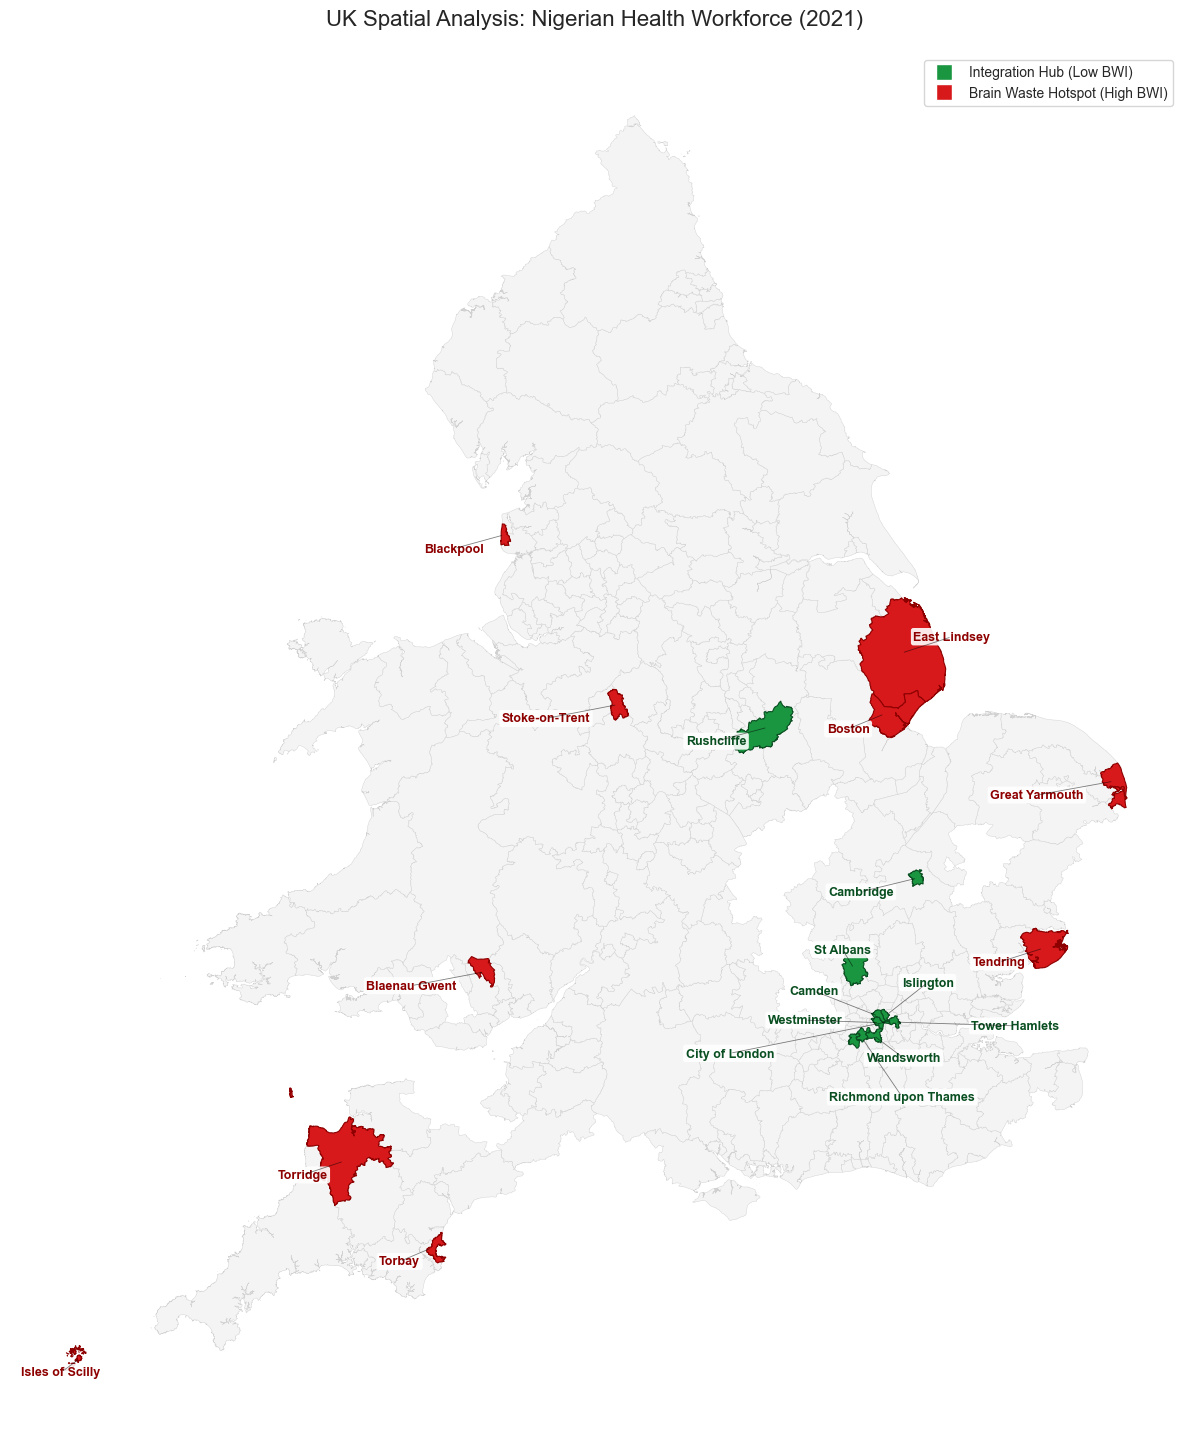

✅ Map with labels saved to: C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\results\visible_labeled_map.png


In [99]:

from matplotlib.lines import Line2D
from adjustText import adjust_text

# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')
res_dir = os.path.join(base_path, 'results')
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# Load and Prepare Data
df = pd.read_csv(data_path)
uk_map = gpd.read_file('https://raw.githubusercontent.com/martinjc/UK-GeoJSON/master/json/administrative/gb/lad.json').to_crs(epsg=4326)
m = uk_map.merge(df, left_on='LAD13NM', right_on='area_name')
hubs = m.nsmallest(10, 'bw_index').reset_index()
spots = m.nlargest(10, 'bw_index').reset_index()

# Create the Map
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
m.plot(ax=ax, color='#f4f4f4', edgecolor='#d0d0d0', linewidth=0.3)
hubs.plot(ax=ax, color='#1a9641', edgecolor='#0a4f21', linewidth=0.8)
spots.plot(ax=ax, color='#d7191c', edgecolor='#8e0000', linewidth=0.8)

# Improved Labeling using adjustText
def add_labels_smart(gdf, ax, clr):
    texts = []
    points_x = []
    points_y = []

    for _, row in gdf.iterrows():
        c = row.geometry.representative_point().coords[0]
        points_x.append(c[0])
        points_y.append(c[1])

        t = ax.text(
            c[0], c[1],
            row['area_name'],
            fontsize=9,
            fontweight='bold',
            color=clr,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.9, ec='none')
        )
        texts.append(t)

    
    adjust_text(
        texts,
        x=points_x,
        y=points_y,
        ax=ax,
        expand=(1.5, 2.0),
        force_text=(0.8, 1.5),
        force_points=(0.5, 1.0),
        arrowprops=dict(
            arrowstyle='-',
            color='black',
            lw=0.6,
            alpha=0.5
        ),
        min_arrow_len=5,
        ensure_inside_axes=True
    )

add_labels_smart(spots, ax, '#8e0000')
add_labels_smart(hubs, ax, '#0a4f21')



plt.title('UK Spatial Analysis: Nigerian Health Workforce (2021)', fontsize=16, pad=20)
ax.set_axis_off()
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Integration Hub (Low BWI)',
           markerfacecolor='#1a9641', markersize=12),
    Line2D([0], [0], marker='s', color='w', label='Brain Waste Hotspot (High BWI)',
           markerfacecolor='#d7191c', markersize=12)
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()

out_path = os.path.join(res_dir, 'visible_labeled_map.png')
plt.savefig(out_path, dpi=300)
plt.show()
print(f"✅ Map with labels saved to: {out_path}")

Integration Hubs (Green) are concentrated in London and university cities, where robust healthcare infrastructure and professional networks facilitate high-skilled placement (BWI as low as 0.06).

Brain Waste Hotspots (Red) dominate post-industrial and coastal regions, where high indices (up to 0.55) suggest Nigerian health workers are disproportionately restricted to care-sector roles.
The clustering proves that "Brain Waste" is a localized systemic issue rather than a factor of community size.

# --- START OF SEC3.IPYNB ---

---
Title: "Economic Impacts of Migration"
---

<!-- You have to develop your own headline structure. -->

Analysis of Migration and Remittance Dynamics in Nigeria (2000–2024): 
Scaling,
Correlation, and 
Policy Efficiency

In [ ]:
#Data Cleaning and Analysis (Nigeria to UK Migration Stock)

import pandas as pd
import os

# File path
file_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\Part 3\Economic Impact\Migration stock\raw_migration_stock.xlsx"

# Read Table 1
df = pd.read_excel(file_path, sheet_name="Table 1", skiprows=10)

# Clean column names
df.columns = df.columns.str.strip()

# Strip spaces in name columns
df['Region, development group, country or area of origin'] = (
    df['Region, development group, country or area of origin']
    .astype(str).str.strip()
)

df['Region, development group, country or area of destination'] = (
    df['Region, development group, country or area of destination']
    .astype(str).str.strip()
)

# Automatically find codes for Nigeria and UK
nigeria_code = df.loc[
    df['Region, development group, country or area of origin']
    .str.contains('Nigeria', case=False, na=False),
    'Location code of origin'
].unique()[0]

uk_code = df.loc[
    df['Region, development group, country or area of destination']
    .str.contains('United Kingdom', case=False, na=False),
    'Location code of destination'
].unique()[0]

print("Nigeria code:", nigeria_code)
print("UK code:", uk_code)

# Filter row for Nigeria as origin
nigeria_row = df[df['Location code of origin'] == nigeria_code]

# Identify all year columns 2000–2026
year_cols = [
    col for col in df.columns
    if isinstance(col, str) and any(col.startswith(str(year)) for year in range(2000, 2027))
]

# Extract migration counts for UK
uk_col_candidates = [c for c in df.columns if str(uk_code) in str(c)]

if uk_col_candidates:
    uk_col = uk_col_candidates[0]
    nigeria_to_uk = nigeria_row[year_cols + [uk_col]]
else:
    nigeria_to_uk = nigeria_row[year_cols]

# output folder + filename
output_folder = r"c:\Users\ZIZIPHO\Desktop\DataScienceLab"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, "nigeria_to_uk_migration_2000_2026.csv")

# Save to CSV
nigeria_to_uk.to_csv(output_path, index=False)

print("Filtered Nigeria → UK migration (2000–2026) saved at:", output_path)
print(nigeria_to_uk)

Nigeria code: 566
UK code: 826
Filtered Nigeria → UK migration (2000–2026) saved at: c:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_to_uk_migration_2000_2026.csv
       2000.1  2005.1  2010.1  2015.1  2020.1   2024.1  2000.2  2005.2  \
84     298175  426869  536809  722576  947270  1099316  243965  337122   
370    144478  184659  211165  292058  353023   392744  111025  141490   
597     17467   22308   23844   28607   36440    52288   13837   16128   
776       408     378     380     502     471      462     380     331   
931      2017    2680    3150    3744    5003     5358     517     648   
...       ...     ...     ...     ...     ...      ...     ...     ...   
25881    4525    7580   14990   25136   38980    56121    3557    6314   
26093   69664   96515  117513  168524  240635   285451   55839   71206   
26239    1113    1565    2741    5060    8212    11262     699    1035   
26495    1113    1565    2741    5060    8212    11262     699    1035   
26746    1113    1565  

In [ ]:
# Total migration from Nigeria to the UK (2000–2026)

import pandas as pd

# Load your filtered CSV
df = pd.read_csv(r"c:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_to_uk_migration_2000_2026.csv")

# Sum across all rows to get total migration per year
total_migration = df.sum(axis=0)

# make a clean table
clean_df = pd.DataFrame({
    'Year': total_migration.index,
    'Number of Migrants': total_migration.values
})

clean_df.to_csv(r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_to_uk_migration_totals_2000_2004.csv", index=False)

print(clean_df)

      Year  Number of Migrants
0   2000.1             2935764
1   2005.1             4103056
2   2010.1             5058710
3   2015.1             6824936
4   2020.1             8817306
5   2024.1            10177871
6   2000.2             2372601
7   2005.2             3222717
8   2010.2             4085094
9   2015.2             5992138
10  2020.2             7684414
11  2024.2             9192164


In [16]:
import sys
!{sys.executable} -m pip install xlrd

  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
#Total remittances from Nigeria to the UK (2000-2024)

import pandas as pd

# File path
file_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\Part 3\Economic Impact\Remittances\raw_remittances.xls"

# Read Excel (skip metadata rows)
df = pd.read_excel(file_path, sheet_name=0, skiprows=3)

# Check columns
print("Columns in dataset:")
print(df.columns)

# The country name column (column 4)
country_col = df.columns[0]   # usually "Country Name"

# Filter for Nigeria
nigeria_df = df[df[country_col].str.contains("Nigeria", case=False, na=False)]

# Extract year columns from 2000 to 2024
year_cols = [col for col in df.columns if str(col).isdigit() and 2000 <= int(col) <= 2024]

# Keep only Nigeria and the selected years
result = nigeria_df[[country_col] + year_cols]

# Save cleaned CSV
output_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_remittances_2000_2024.csv"
result.to_csv(output_path, index=False)

print("Nigeria remittances extracted successfully.")
print("Saved to:", output_path)

# Preview
print(result)

Columns in dataset:
Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025'],
      dtype='str')
Nigeria remittances extracted successfully.
Saved to: C:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_remittances_2000_2024.csv
    Country Name          2000           2001           2002          2003  \
174      Nigeria  1.052142e+06  593358.431196  903977.979981  1.156224e+07   

             200

   Year  total_remittances  number_of_migrants
0  2000       1.052142e+06               83822
1  2005       6.803027e+07              125003
2  2010       4.747469e+07              189847
3  2015       1.035451e+09              236603
4  2020       9.210166e+07              286251
Index(['Year', 'total_remittances', 'number_of_migrants'], dtype='str')

Correlation between Remittances and Migrants: 0.22


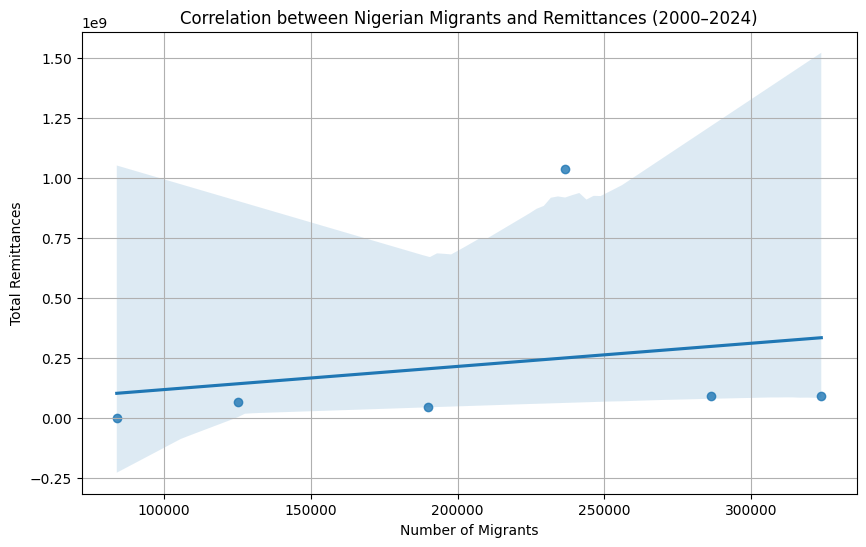

In [ ]:
#Correlation between Nigerian Migrants and Remittances (2000–2024)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# File path (your merged dataset)
file_path = r"C:\Users\ZIZIPHO\Desktop\MSc Data Engineering\Python Programming for DE\Tutorials\Fundamentals_PythonNtshatsha\DataScienceLab_Migration\data_processed\merged_migration_remittances 1(in).csv"

# Load the merged data
df = pd.read_csv(file_path)

# Inspect data
print(df.head())
print(df.columns)

# Clean column names (strip spaces and convert to lowercase with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Make sure correct data types
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['total_remittances'] = pd.to_numeric(df['total_remittances'], errors='coerce')
df['number_of_migrants'] = pd.to_numeric(df['number_of_migrants'], errors='coerce')

# Drop missing values
df = df.dropna()

# Correlation
correlation = df['total_remittances'].corr(df['number_of_migrants'])
print(f"\nCorrelation between Remittances and Migrants: {correlation:.2f}")

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    x=df['number_of_migrants'], 
    y=df['total_remittances'], 
    marker='o'
)

plt.title('Correlation between Nigerian Migrants and Remittances (2000–2024)')
plt.xlabel('Number of Migrants')
plt.ylabel('Total Remittances')
plt.grid(True)
plt.show()

The graph shows a weak positive relationship between the number of migrants and total remittances. Each point represents a specific year, plotting migration against remittance inflows. The upward-sloping trend line suggests that remittances tend to increase as migration rises. However, the low correlation coefficient (0.22) indicates that this relationship is not strong. The wide spread of points and the large confidence interval suggest that other factors, beyond migration, significantly influence remittance flows.

Reason for the spike in 2015?

In 2015:
Nigeria faced falling oil prices (major income source) and coursed Economic uncertainty.
Global evidence shows that low oil prices and economic stress affect remittance behavior.
Reference: International Monetary Fund. (2016). IMF Executive Board Concludes 2016 Article IV Consultation with Nigeria. IMF

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'total_remittances': [1.052142e6, 6.803027e7, 4.747469e7, 1.035451e9, 9.210166e7],
    'number_of_migrants': [83822, 125003, 189847, 236603, 286251]
}

df = pd.DataFrame(data)

# scale
scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled[['remittances_scaled', 'migrants_scaled']] = scaler.fit_transform(
    df[['total_remittances', 'number_of_migrants']]
)

#policy index (weighted)
df_scaled['Policy_Index'] = (
    0.7 * df_scaled['remittances_scaled']
    - 0.3 * df_scaled['migrants_scaled']
)

print(df_scaled)


   Year  total_remittances  number_of_migrants  remittances_scaled  \
0  2000       1.052142e+06               83822            0.000000   
1  2005       6.803027e+07              125003            0.064751   
2  2010       4.747469e+07              189847            0.044879   
3  2015       1.035451e+09              236603            1.000000   
4  2020       9.210166e+07              286251            0.088022   

   migrants_scaled  Policy_Index  
0         0.000000      0.000000  
1         0.203434     -0.015705  
2         0.523764     -0.125714  
3         0.754739      0.473578  
4         1.000000     -0.238385  


The policy index assigns a weight of 70% to remittances and 30% to migration, reflecting the assumption that economic gains are more important than the costs associated with human migration. The negative sign for migration indicates that higher migration is treated as a loss.

The results show that 2015 achieved the highest policy efficiency, as strong remittance inflows outweighed the costs of migration. In contrast, 2020 recorded the lowest score, indicating that high migration was not matched by sufficient financial returns. Overall, the findings suggest that migration only contributes positively to policy outcomes when it generates substantial economic benefits.

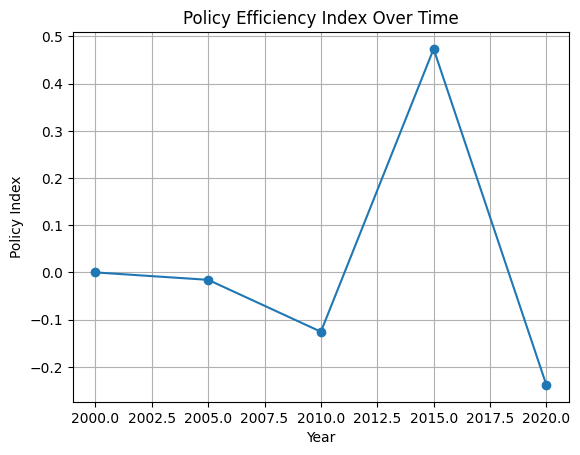

In [18]:
import matplotlib.pyplot as plt

plt.plot(df_scaled['Year'], df_scaled['Policy_Index'], marker='o')
plt.title("Policy Efficiency Index Over Time")
plt.xlabel("Year")
plt.ylabel("Policy Index")
plt.grid()
plt.show()